Device: cpu
[latent=2, h=256] ep 1/4 | train=225.53 | val=188.75
[latent=2, h=256] ep 2/4 | train=181.74 | val=173.86
[latent=2, h=256] ep 3/4 | train=170.96 | val=167.09
[latent=2, h=256] ep 4/4 | train=165.48 | val=163.51
[latent=10, h=256] ep 1/4 | train=230.09 | val=194.23
[latent=10, h=256] ep 2/4 | train=185.18 | val=171.09
[latent=10, h=256] ep 3/4 | train=156.36 | val=145.36
[latent=10, h=256] ep 4/4 | train=140.29 | val=133.70
[latent=20, h=512] ep 1/4 | train=216.50 | val=187.75
[latent=20, h=512] ep 2/4 | train=171.62 | val=153.23
[latent=20, h=512] ep 3/4 | train=144.19 | val=135.87
[latent=20, h=512] ep 4/4 | train=131.62 | val=126.57
[latent=10, h=128, tanh] ep 1/4 | train=284.01 | val=212.47
[latent=10, h=128, tanh] ep 2/4 | train=209.96 | val=207.43
[latent=10, h=128, tanh] ep 3/4 | train=204.63 | val=199.45
[latent=10, h=128, tanh] ep 4/4 | train=196.93 | val=194.52


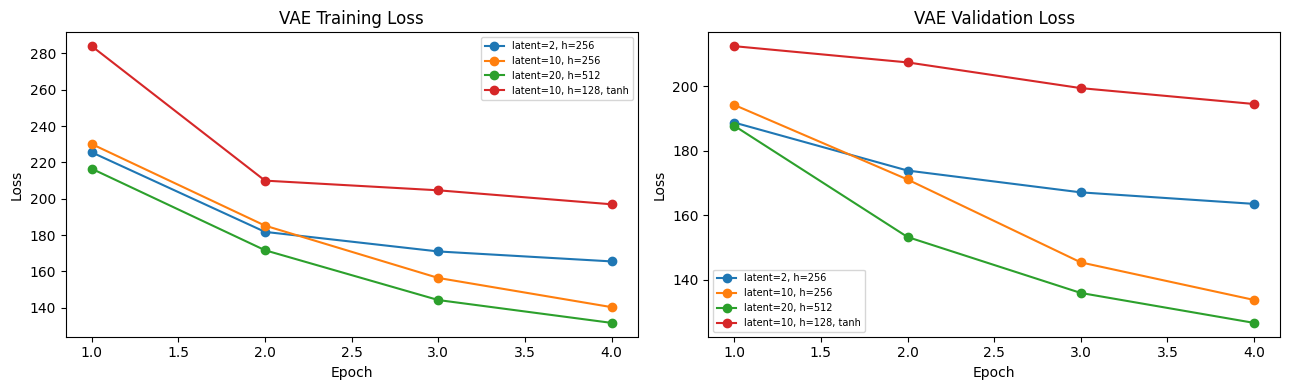

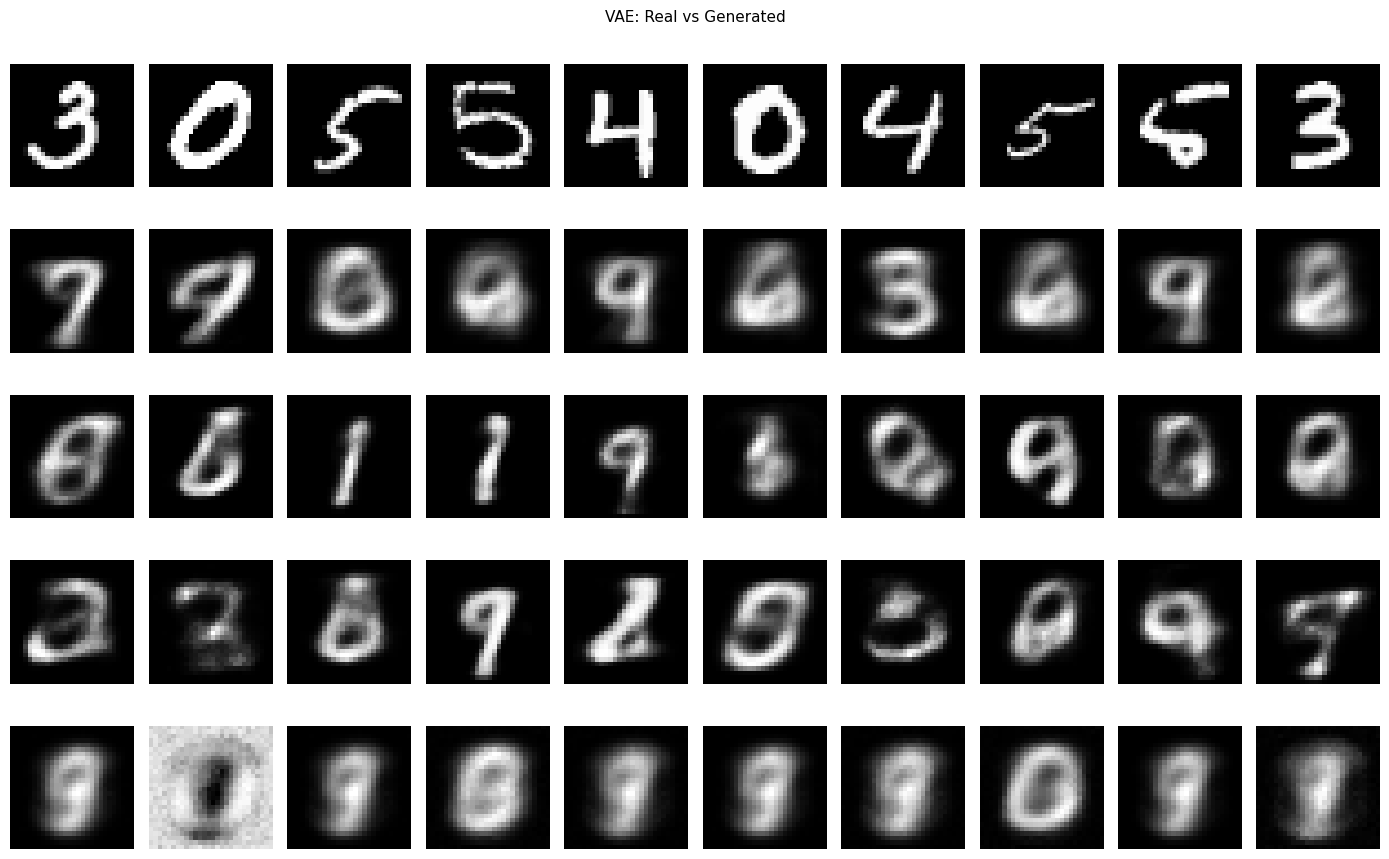

VAE complete


In [1]:
%matplotlib inline
import asyncio, sys
if sys.platform == 'win32':
    asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

t = transforms.ToTensor()
train_set = datasets.MNIST('./data', train=True,  download=True,  transform=t)
val_set   = datasets.MNIST('./data', train=False, download=True,  transform=t)

class VAE(nn.Module):
    def __init__(self, latent_dim=10, hidden_dim=256, activation=nn.ReLU):
        super().__init__()
        act = activation
        self.enc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, hidden_dim), act(),
            nn.Linear(hidden_dim, hidden_dim), act()
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_lv = nn.Linear(hidden_dim, latent_dim)
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), act(),
            nn.Linear(hidden_dim, hidden_dim), act(),
            nn.Linear(hidden_dim, 784), nn.Sigmoid()
        )
    def encode(self, x):
        h = self.enc(x)
        return self.fc_mu(h), self.fc_lv(h)
    def decode(self, z):
        return self.dec(z)
    def forward(self, x):
        mu, lv = self.encode(x)
        z = mu + torch.exp(0.5 * lv) * torch.randn_like(mu)
        return self.decode(z), mu, lv

def vae_loss(rx, x, mu, lv):
    bce = F.binary_cross_entropy(rx, x.view(-1, 784), reduction='sum') / x.size(0)
    kld = -0.5 * torch.mean(torch.sum(1 + lv - mu.pow(2) - lv.exp(), dim=1))
    return bce + kld

vae_configs = [
    {'latent_dim':  2, 'hidden_dim': 256, 'lr': 1e-3, 'activation': nn.ReLU, 'name': 'latent=2, h=256'},
    {'latent_dim': 10, 'hidden_dim': 256, 'lr': 1e-3, 'activation': nn.ReLU, 'name': 'latent=10, h=256'},
    {'latent_dim': 20, 'hidden_dim': 512, 'lr': 1e-3, 'activation': nn.ReLU, 'name': 'latent=20, h=512'},
    {'latent_dim': 10, 'hidden_dim': 128, 'lr': 5e-4, 'activation': nn.Tanh, 'name': 'latent=10, h=128, tanh'},
]

EPOCHS_VAE = 4
vae_results = {}

for cfg in vae_configs:
    model = VAE(cfg['latent_dim'], cfg['hidden_dim'], cfg['activation']).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=cfg['lr'])
    tr_loader = DataLoader(train_set, batch_size=512, shuffle=True,  num_workers=0)
    va_loader = DataLoader(val_set,   batch_size=512, shuffle=False, num_workers=0)
    tl, vl = [], []
    for ep in range(EPOCHS_VAE):
        model.train()
        running = 0.0
        for x, _ in tr_loader:
            x = x.to(device)
            opt.zero_grad()
            rx, mu, lv = model(x)
            loss = vae_loss(rx, x, mu, lv)
            loss.backward()
            opt.step()
            running += loss.item()
        tl.append(running / len(tr_loader))
        model.eval()
        running = 0.0
        with torch.no_grad():
            for x, _ in va_loader:
                x = x.to(device)
                rx, mu, lv = model(x)
                running += vae_loss(rx, x, mu, lv).item()
        vl.append(running / len(va_loader))
        print(f"[{cfg['name']}] ep {ep+1}/{EPOCHS_VAE} | train={tl[-1]:.2f} | val={vl[-1]:.2f}")
    vae_results[cfg['name']] = {'model': model, 'train': tl, 'val': vl, 'cfg': cfg}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
for name, r in vae_results.items():
    ax1.plot(range(1, EPOCHS_VAE+1), r['train'], marker='o', label=name)
    ax2.plot(range(1, EPOCHS_VAE+1), r['val'],   marker='o', label=name)
ax1.set_title('VAE Training Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend(fontsize=7)
ax2.set_title('VAE Validation Loss'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.legend(fontsize=7)
plt.tight_layout(); plt.show()

real_imgs, _ = next(iter(DataLoader(val_set, batch_size=10, shuffle=True)))
n_rows = len(vae_results) + 1
fig, axes = plt.subplots(n_rows, 10, figsize=(14, 1.8 * n_rows))
for j in range(10):
    axes[0, j].imshow(real_imgs[j].squeeze(), cmap='gray'); axes[0, j].axis('off')
axes[0, 0].set_ylabel('Real', fontsize=9)
for i, (name, r) in enumerate(vae_results.items()):
    m = r['model'].eval()
    with torch.no_grad():
        z = torch.randn(10, r['cfg']['latent_dim']).to(device)
        gen = m.decode(z).view(10, 28, 28).cpu().numpy()
    for j in range(10):
        axes[i+1, j].imshow(gen[j], cmap='gray'); axes[i+1, j].axis('off')
    axes[i+1, 0].set_ylabel(name[:18], fontsize=7)
plt.suptitle('VAE: Real vs Generated', fontsize=11)
plt.tight_layout(); plt.show()
print('VAE complete')

Looking at my results, increasing the latent space dimension generally helped image quality. The latent=2 config had the highest loss and produced the blurriest outputs -- makes sense because squeezing a 784-pixel image into just 2 numbers means the model has to throw away most of the information, so the decoder has almost nothing to work with. When I went up to latent=10 and then latent=20 with a larger hidden size of 512, the losses dropped and the generated digits looked cleaner and more recognizable. The latent=10, h=128, tanh config did the worst overall: the smaller hidden layer can't capture as much, and tanh tends to flatten out more than ReLU, which slows down learning. Basically, a bigger latent space gives the encoder more room to store things like stroke shape and curves, so the decoder can do a better job reconstructing the image. That said, going too big can make the latent space less smooth, which hurts quality when you sample randomly from a standard normal instead of encoding a real image.

[noise=64,  h=64] ep 1/3 | G=0.6629 | D=0.9741
[noise=64,  h=64] ep 2/3 | G=0.7565 | D=1.0862
[noise=64,  h=64] ep 3/3 | G=0.9316 | D=1.0215
[noise=100, h=128] ep 1/3 | G=0.6370 | D=1.1077
[noise=100, h=128] ep 2/3 | G=0.7593 | D=1.1770
[noise=100, h=128] ep 3/3 | G=0.9244 | D=1.0837
[noise=128, h=128, lr=1e-4] ep 1/3 | G=0.5915 | D=1.0527
[noise=128, h=128, lr=1e-4] ep 2/3 | G=0.6157 | D=1.2161
[noise=128, h=128, lr=1e-4] ep 3/3 | G=0.7698 | D=1.1103
[noise=64,  h=128, lr=5e-4] ep 1/3 | G=0.8214 | D=1.1865
[noise=64,  h=128, lr=5e-4] ep 2/3 | G=0.7800 | D=1.2828
[noise=64,  h=128, lr=5e-4] ep 3/3 | G=0.9637 | D=1.1646


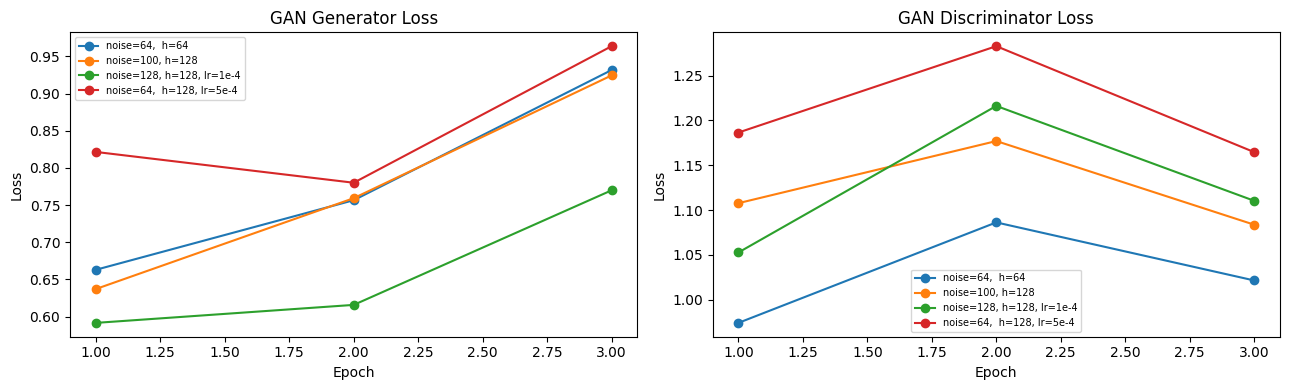

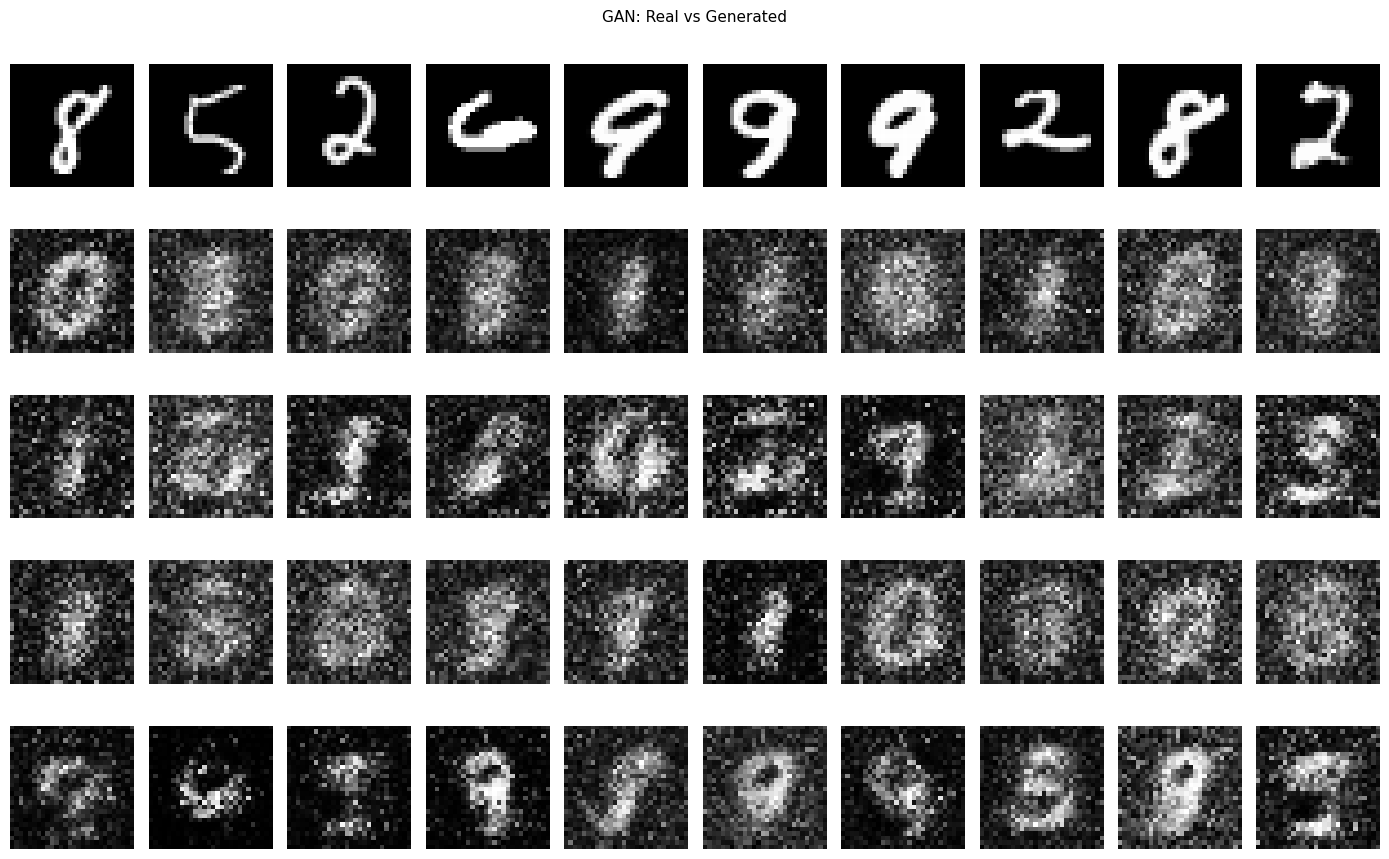

GAN complete


In [2]:
t_norm = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
gan_train = datasets.MNIST('./data', train=True,  download=False, transform=t_norm)

class Generator(nn.Module):
    def __init__(self, noise_dim=64, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, hidden),     nn.LeakyReLU(0.2),
            nn.Linear(hidden, hidden * 2),    nn.BatchNorm1d(hidden * 2), nn.LeakyReLU(0.2),
            nn.Linear(hidden * 2, 784),       nn.Tanh()
        )
    def forward(self, z): return self.net(z).view(-1, 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, hidden * 2),    nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(hidden * 2, hidden), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(hidden, 1),          nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

gan_configs = [
    {'noise': 64,  'hidden': 64,  'lr': 2e-4, 'name': 'noise=64,  h=64'},
    {'noise': 100, 'hidden': 128, 'lr': 2e-4, 'name': 'noise=100, h=128'},
    {'noise': 128, 'hidden': 128, 'lr': 1e-4, 'name': 'noise=128, h=128, lr=1e-4'},
    {'noise': 64,  'hidden': 128, 'lr': 5e-4, 'name': 'noise=64,  h=128, lr=5e-4'},
]

EPOCHS_GAN = 3
criterion  = nn.BCELoss()
gan_results = {}

for cfg in gan_configs:
    G = Generator(cfg['noise'], cfg['hidden']).to(device)
    D = Discriminator(cfg['hidden']).to(device)
    opt_G = torch.optim.Adam(G.parameters(), lr=cfg['lr'], betas=(0.5, 0.999))
    opt_D = torch.optim.Adam(D.parameters(), lr=cfg['lr'], betas=(0.5, 0.999))
    loader = DataLoader(gan_train, batch_size=512, shuffle=True, num_workers=0)
    g_hist, d_hist = [], []
    for ep in range(EPOCHS_GAN):
        G.train(); D.train()
        g_run = d_run = 0.0
        for x, _ in loader:
            x = x.to(device)
            b = x.size(0)
            real_lbl = torch.ones(b,  1, device=device)
            fake_lbl = torch.zeros(b, 1, device=device)
            z = torch.randn(b, cfg['noise'], device=device)
            d_loss = criterion(D(x), real_lbl) + criterion(D(G(z).detach()), fake_lbl)
            opt_D.zero_grad(); d_loss.backward(); opt_D.step()
            z = torch.randn(b, cfg['noise'], device=device)
            g_loss = criterion(D(G(z)), real_lbl)
            opt_G.zero_grad(); g_loss.backward(); opt_G.step()
            g_run += g_loss.item(); d_run += d_loss.item()
        g_hist.append(g_run / len(loader))
        d_hist.append(d_run / len(loader))
        print(f"[{cfg['name']}] ep {ep+1}/{EPOCHS_GAN} | G={g_hist[-1]:.4f} | D={d_hist[-1]:.4f}")
    gan_results[cfg['name']] = {'G': G, 'g': g_hist, 'd': d_hist, 'cfg': cfg}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
for name, r in gan_results.items():
    ax1.plot(range(1, EPOCHS_GAN+1), r['g'], marker='o', label=name)
    ax2.plot(range(1, EPOCHS_GAN+1), r['d'], marker='o', label=name)
ax1.set_title('GAN Generator Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend(fontsize=7)
ax2.set_title('GAN Discriminator Loss'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.legend(fontsize=7)
plt.tight_layout(); plt.show()

real_disp, _ = next(iter(DataLoader(val_set, batch_size=10, shuffle=True)))
n_rows = len(gan_results) + 1
fig, axes = plt.subplots(n_rows, 10, figsize=(14, 1.8 * n_rows))
for j in range(10):
    axes[0, j].imshow(real_disp[j].squeeze(), cmap='gray'); axes[0, j].axis('off')
axes[0, 0].set_ylabel('Real', fontsize=9)
for i, (name, r) in enumerate(gan_results.items()):
    G = r['G'].eval()
    with torch.no_grad():
        z = torch.randn(10, r['cfg']['noise'], device=device)
        gen = (G(z) * 0.5 + 0.5).cpu().squeeze(1).numpy()
    for j in range(10):
        axes[i+1, j].imshow(gen[j], cmap='gray'); axes[i+1, j].axis('off')
    axes[i+1, 0].set_ylabel(name[:18], fontsize=7)
plt.suptitle('GAN: Real vs Generated', fontsize=11)
plt.tight_layout(); plt.show()
print('GAN complete')

Looking at my loss curves, the generator loss kept going up across all 3 epochs while the discriminator loss peaked at epoch 2 and then came back down. This means the discriminator was clearly winning. This makes sense given the setup: the discriminator uses dropout and gets two rounds of gradient updates per batch while the generator only gets one. When the discriminator gets too good too fast, it becomes very confident that fake images are fake, which leaves the generator with very weak gradients to learn from. This is one of the main reasons GAN training is so unstable. If training were going well, I'd expect the generator loss to come down while the discriminator loss settles near 0.693, which is log(2) and the point where the discriminator can no longer tell real from fake. Instead they're moving apart, and you can see this in the generated images: they're noisy and hard to make out. With more epochs and tricks like label smoothing or slowing down the discriminator's learning rate, the outputs would get a lot better.

Using 16 patches of 49 pixels each
[emb=64,  h=2, ff=128, L=2] ep 1/3 | train=0.4597 | val=0.3447
[emb=64,  h=2, ff=128, L=2] ep 2/3 | train=0.3075 | val=0.2814
[emb=64,  h=2, ff=128, L=2] ep 3/3 | train=0.2688 | val=0.2530
[emb=128, h=2, ff=256, L=2] ep 1/3 | train=0.3796 | val=0.2833
[emb=128, h=2, ff=256, L=2] ep 2/3 | train=0.2660 | val=0.2483
[emb=128, h=2, ff=256, L=2] ep 3/3 | train=0.2403 | val=0.2304
[emb=64,  h=4, ff=256, L=4] ep 1/3 | train=0.4256 | val=0.3185
[emb=64,  h=4, ff=256, L=4] ep 2/3 | train=0.2902 | val=0.2675
[emb=64,  h=4, ff=256, L=4] ep 3/3 | train=0.2546 | val=0.2400
[emb=128, h=4, ff=256, L=4] ep 1/3 | train=0.4210 | val=0.3183
[emb=128, h=4, ff=256, L=4] ep 2/3 | train=0.2910 | val=0.2703
[emb=128, h=4, ff=256, L=4] ep 3/3 | train=0.2585 | val=0.2430


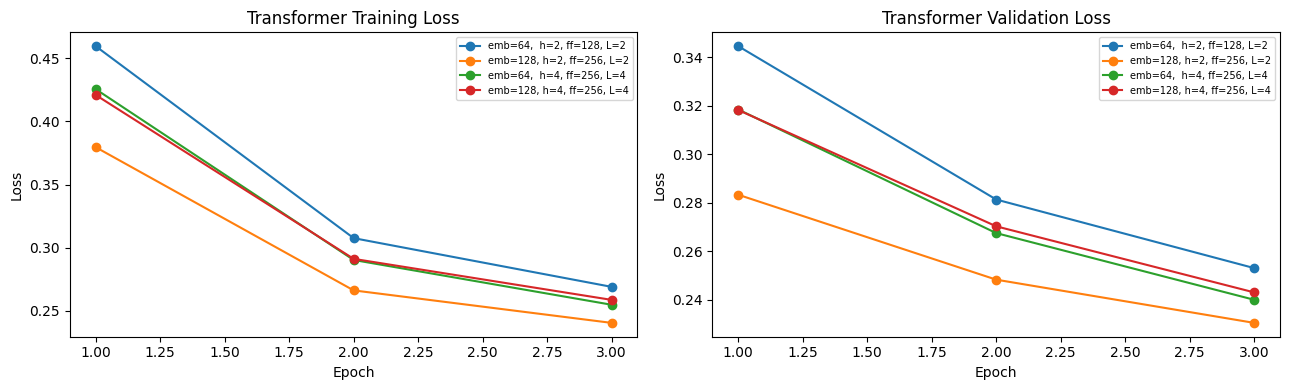

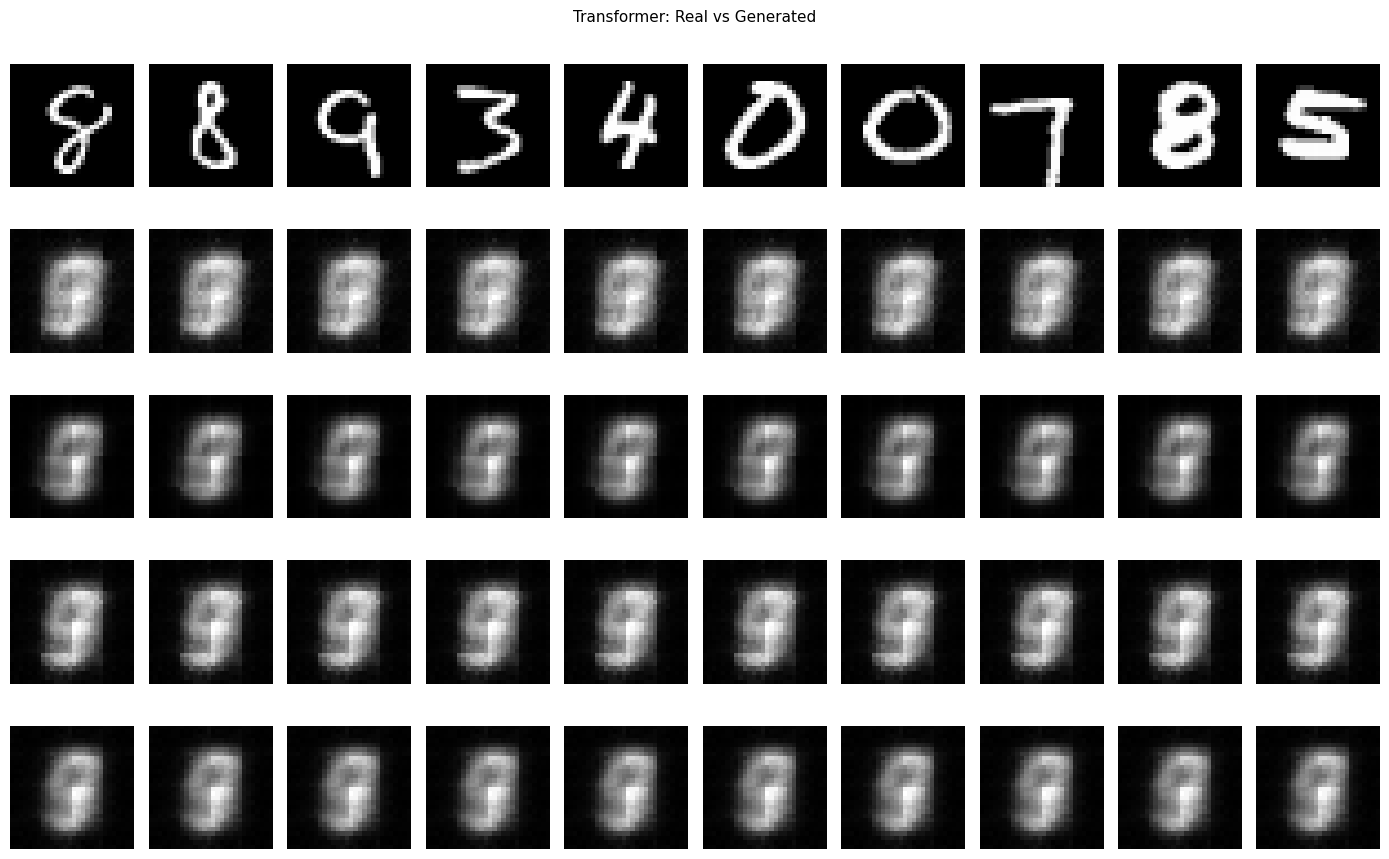

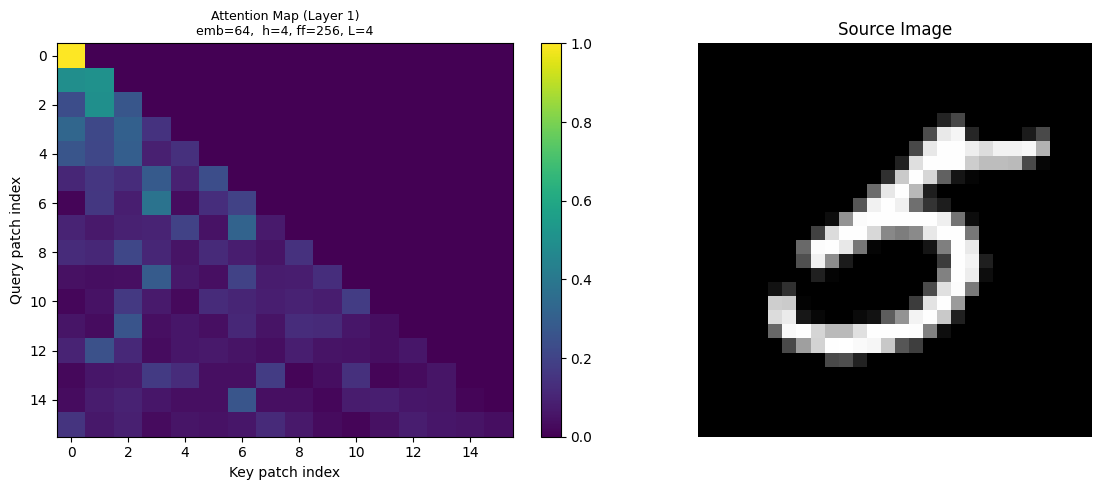

Transformer complete


In [3]:
PATCH     = 7
N_PATCHES = (28 // PATCH) ** 2
PATCH_DIM  = PATCH * PATCH
print(f'Using {N_PATCHES} patches of {PATCH_DIM} pixels each')

def img_to_patches(imgs):
    b = imgs.size(0)
    x = imgs.view(b, 28, 28)
    n = 28 // PATCH
    patches = x.unfold(1, PATCH, PATCH).unfold(2, PATCH, PATCH)
    return patches.contiguous().view(b, n * n, PATCH_DIM)

def patches_to_img(patches):
    b = patches.size(0)
    n = 28 // PATCH
    p = patches.view(b, n, n, PATCH, PATCH)
    p = p.permute(0, 1, 3, 2, 4).contiguous()
    return p.view(b, n * PATCH, n * PATCH)

class GPTBlock(nn.Module):
    def __init__(self, emb_dim, n_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(emb_dim, n_heads, dropout=dropout, batch_first=True)
        self.ff   = nn.Sequential(
            nn.Linear(emb_dim, ff_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(ff_dim, emb_dim), nn.Dropout(dropout)
        )
        self.ln1 = nn.LayerNorm(emb_dim)
        self.ln2 = nn.LayerNorm(emb_dim)
    def forward(self, x, mask=None, return_weights=False):
        normed = self.ln1(x)
        a, w = self.attn(normed, normed, normed, attn_mask=mask, need_weights=return_weights)
        x = x + a
        x = x + self.ff(self.ln2(x))
        return (x, w) if return_weights else x

class PatchGPT(nn.Module):
    def __init__(self, emb_dim=64, n_heads=2, ff_dim=128, n_layers=2):
        super().__init__()
        self.patch_proj  = nn.Linear(PATCH_DIM, emb_dim)
        self.start_token = nn.Parameter(torch.randn(1, 1, emb_dim))
        self.pos_emb     = nn.Embedding(N_PATCHES, emb_dim)
        self.blocks      = nn.ModuleList([GPTBlock(emb_dim, n_heads, ff_dim) for _ in range(n_layers)])
        self.ln_f        = nn.LayerNorm(emb_dim)
        self.head        = nn.Linear(emb_dim, PATCH_DIM)
    def causal_mask(self, n, device):
        return torch.triu(torch.ones(n, n, device=device), diagonal=1).bool()
    def forward(self, patches):
        b = patches.size(0)
        start = self.start_token.expand(b, 1, -1)
        emb   = self.patch_proj(patches)
        seq   = torch.cat([start, emb[:, :-1]], dim=1)
        seq   = seq + self.pos_emb(torch.arange(N_PATCHES, device=patches.device))
        mask  = self.causal_mask(N_PATCHES, patches.device)
        for block in self.blocks:
            seq = block(seq, mask=mask)
        return self.head(self.ln_f(seq))
    def get_attention(self, patches):
        b = patches.size(0)
        start = self.start_token.expand(b, 1, -1)
        emb   = self.patch_proj(patches)
        seq   = torch.cat([start, emb[:, :-1]], dim=1)
        seq   = seq + self.pos_emb(torch.arange(N_PATCHES, device=patches.device))
        mask  = self.causal_mask(N_PATCHES, patches.device)
        seq, attn_w = self.blocks[0](seq, mask=mask, return_weights=True)
        for block in self.blocks[1:]:
            seq = block(seq, mask=mask)
        return attn_w
    @torch.no_grad()
    def generate(self, n_samples=10, dev='cpu'):
        self.eval()
        samples = []
        for _ in range(n_samples):
            raw_ctx = [self.start_token.to(dev)]
            gen_patches = []
            for i in range(N_PATCHES):
                ctx  = torch.cat(raw_ctx, dim=1)
                n_   = ctx.size(1)
                x    = ctx + self.pos_emb(torch.arange(n_, device=dev))
                mask = self.causal_mask(n_, dev)
                for block in self.blocks:
                    x = block(x, mask=mask)
                x = self.ln_f(x)
                nxt = torch.sigmoid(self.head(x[:, -1:]))
                gen_patches.append(nxt)
                raw_ctx.append(self.patch_proj(nxt))
            samples.append(torch.cat(gen_patches, dim=1).squeeze(0))
        return torch.stack(samples)

tr_sub = Subset(train_set, list(range(10000)))

tr_configs = [
    {'emb':  64, 'heads': 2, 'ff': 128, 'layers': 2, 'lr': 1e-3, 'name': 'emb=64,  h=2, ff=128, L=2'},
    {'emb': 128, 'heads': 2, 'ff': 256, 'layers': 2, 'lr': 1e-3, 'name': 'emb=128, h=2, ff=256, L=2'},
    {'emb':  64, 'heads': 4, 'ff': 256, 'layers': 4, 'lr': 1e-3, 'name': 'emb=64,  h=4, ff=256, L=4'},
    {'emb': 128, 'heads': 4, 'ff': 256, 'layers': 4, 'lr': 5e-4, 'name': 'emb=128, h=4, ff=256, L=4'},
]

EPOCHS_TR = 3
tr_results = {}

for cfg in tr_configs:
    model = PatchGPT(cfg['emb'], cfg['heads'], cfg['ff'], cfg['layers']).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=cfg['lr'])
    tr_loader = DataLoader(tr_sub,  batch_size=256, shuffle=True,  num_workers=0)
    va_loader = DataLoader(val_set, batch_size=256, shuffle=False, num_workers=0)
    tl, vl = [], []
    for ep in range(EPOCHS_TR):
        model.train()
        running = 0.0
        for x, _ in tr_loader:
            x = x.to(device)
            patches = img_to_patches(x)
            loss = F.binary_cross_entropy_with_logits(model(patches), patches)
            opt.zero_grad(); loss.backward(); opt.step()
            running += loss.item()
        tl.append(running / len(tr_loader))
        model.eval()
        running = 0.0
        with torch.no_grad():
            for x, _ in va_loader:
                x = x.to(device)
                patches = img_to_patches(x)
                running += F.binary_cross_entropy_with_logits(model(patches), patches).item()
        vl.append(running / len(va_loader))
        print(f"[{cfg['name']}] ep {ep+1}/{EPOCHS_TR} | train={tl[-1]:.4f} | val={vl[-1]:.4f}")
    tr_results[cfg['name']] = {'model': model, 'train': tl, 'val': vl, 'cfg': cfg}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
for name, r in tr_results.items():
    ax1.plot(range(1, EPOCHS_TR+1), r['train'], marker='o', label=name)
    ax2.plot(range(1, EPOCHS_TR+1), r['val'],   marker='o', label=name)
ax1.set_title('Transformer Training Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend(fontsize=7)
ax2.set_title('Transformer Validation Loss'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.legend(fontsize=7)
plt.tight_layout(); plt.show()

real_imgs3, _ = next(iter(DataLoader(val_set, batch_size=10, shuffle=True)))
n_rows = len(tr_results) + 1
fig, axes = plt.subplots(n_rows, 10, figsize=(14, 1.8 * n_rows))
for j in range(10):
    axes[0, j].imshow(real_imgs3[j].squeeze(), cmap='gray'); axes[0, j].axis('off')
axes[0, 0].set_ylabel('Real', fontsize=9)
best_name = list(tr_results.keys())[2]
for i, (name, r) in enumerate(tr_results.items()):
    m = r['model']
    gen_p = m.generate(10, dev=str(device))
    imgs  = patches_to_img(gen_p).numpy()
    for j in range(10):
        axes[i+1, j].imshow(np.clip(imgs[j], 0, 1), cmap='gray'); axes[i+1, j].axis('off')
    axes[i+1, 0].set_ylabel(name[:18], fontsize=7)
plt.suptitle('Transformer: Real vs Generated', fontsize=11)
plt.tight_layout(); plt.show()

best_model = tr_results[best_name]['model'].eval()
sample_x, _ = next(iter(DataLoader(val_set, batch_size=1, shuffle=True)))
sample_patches = img_to_patches(sample_x.to(device))
with torch.no_grad():
    attn_w = best_model.get_attention(sample_patches).squeeze(0).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im = axes[0].imshow(attn_w, cmap='viridis', aspect='auto')
axes[0].set_title(f'Attention Map (Layer 1)\n{best_name}', fontsize=9)
axes[0].set_xlabel('Key patch index'); axes[0].set_ylabel('Query patch index')
plt.colorbar(im, ax=axes[0])
axes[1].imshow(sample_x[0].squeeze(), cmap='gray')
axes[1].set_title('Source Image'); axes[1].axis('off')
plt.tight_layout(); plt.show()
print('Transformer complete')

My transformer cuts each 28x28 image into 16 non-overlapping 7x7 patches and trains like a GPT, predicting each patch one at a time based on all the ones before it, using a causal mask so it can't peek ahead. All 4 configs trained well, with emb=128, h=2, ff=256 reaching the lowest loss, which suggests that a bigger embedding dimension helps more than adding extra attention heads or layers at this scale. The generated digits are blurry and tend to look similar across rows, which is expected. The model only trains on 10,000 samples for 3 epochs, so it hasn't seen enough variety to produce diverse outputs. As for the attention map from the first transformer block, it comes out lower triangular. Each patch can only look at the patches that came before it. The brighter values along the diagonal and in the lower rows show that later patches mostly pay attention to the ones right before them, which makes sense since patches that are next to each other share the most useful information for filling in digit strokes.